<a href="https://colab.research.google.com/github/sarthakkalra/python-assignment-part4/blob/main/part4_visualization_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/sarthakkalra/python-assignment-part4/refs/heads/main/students.csv")

df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [5]:
df.shape
df.dtypes
df.describe()
df['passed'].value_counts()

,count
passed,
1,9
0,6


In [6]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']

df[df['passed']==1][subject_cols].mean()
df[df['passed']==0][subject_cols].mean()

,0
math,45.166667
science,49.000000
english,46.833333
history,48.333333
pe,58.000000


In [7]:
df['avg_temp'] = df[subject_cols].mean(axis=1)

df.loc[df['avg_temp'].idxmax()]

,3
name,Diana
math,95
science,98
english,91
history,89
pe,97
attendance_pct,98
study_hours_per_day,6.0
passed,1
avg_temp,94.0


In [8]:
df['avg_score'] = df[subject_cols].mean(axis=1)

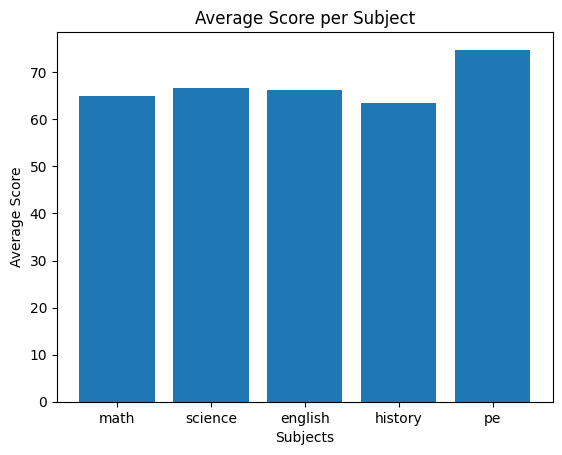

In [9]:
plt.bar(subject_cols, df[subject_cols].mean())
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.show()

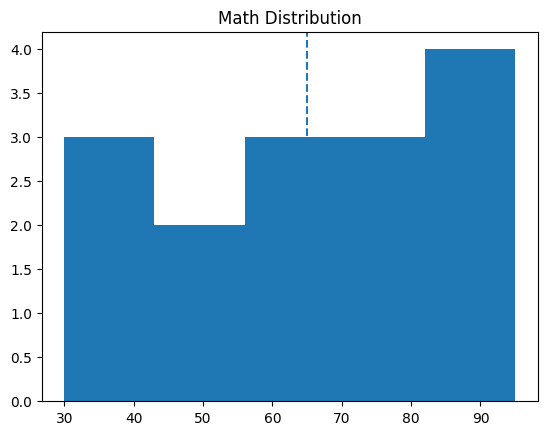

In [10]:
plt.hist(df['math'], bins=5)
plt.axvline(df['math'].mean(), linestyle='dashed')
plt.title("Math Distribution")
plt.show()

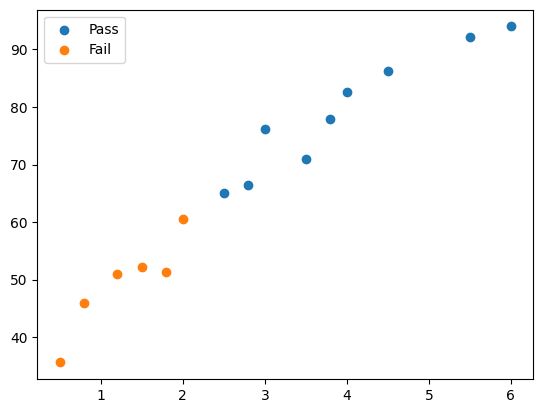

In [11]:
pass_df = df[df['passed']==1]
fail_df = df[df['passed']==0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label='Pass')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label='Fail')

plt.legend()
plt.show()

/tmp/ipykernel_3343/3155413798.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


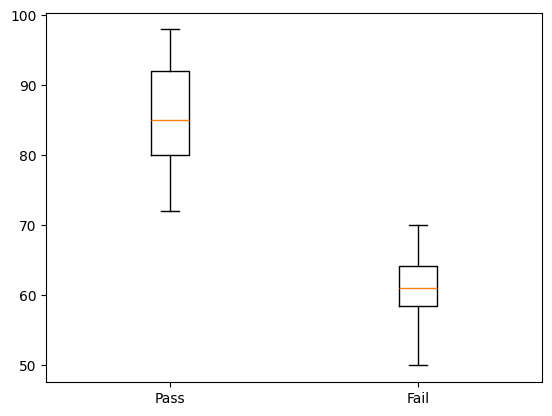

In [12]:
plt.boxplot([
    df[df['passed']==1]['attendance_pct'],
    df[df['passed']==0]['attendance_pct']
], labels=['Pass','Fail'])

plt.show()

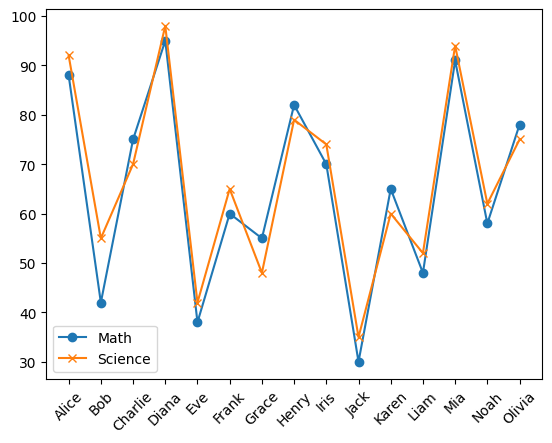

In [13]:
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='x', label='Science')

plt.xticks(rotation=45)
plt.legend()
plt.show()

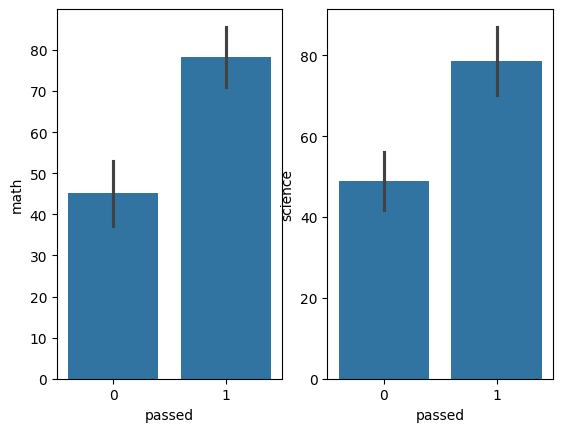

In [14]:
plt.subplot(1,2,1)
sns.barplot(data=df, x='passed', y='math')

plt.subplot(1,2,2)
sns.barplot(data=df, x='passed', y='science')

plt.show()

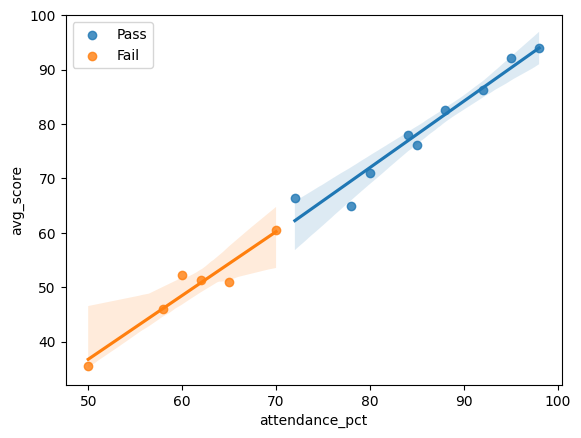

In [15]:
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', label='Pass')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', label='Fail')

plt.legend()
plt.show()

In [16]:
# Seaborn is easier for statistical visualization and requires less code.
# Matplotlib gives more control but needs more manual setup.

In [17]:
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

model.score(X_train_scaled, y_train)

1.0

In [20]:
y_pred = model.predict(X_test_scaled)

accuracy_score(y_test, y_pred)

1.0

In [21]:
names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(names, y_test, y_pred):
    print(name, actual, pred, "✅" if actual==pred else "❌")

Jack 0 0 ✅
Liam 0 0 ✅
Alice 1 1 ✅


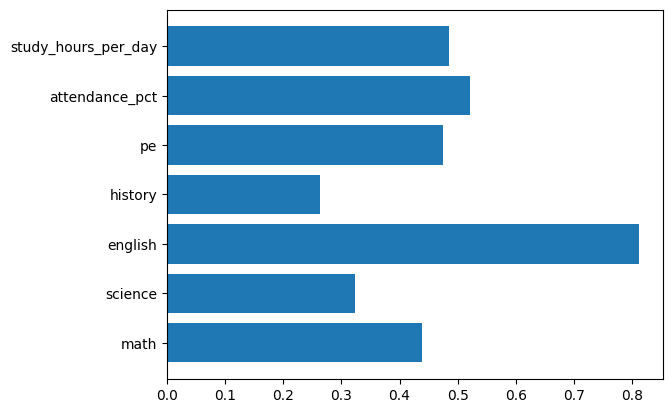

In [22]:
coeffs = model.coef_[0]
features = X.columns

plt.barh(features, coeffs)
plt.show()

In [24]:
new_student = [[75,70,68,65,80,82,3.2]]
new_student_df = pd.DataFrame(new_student, columns=X.columns)
new_scaled = scaler.transform(new_student_df)

model.predict(new_scaled)
model.predict_proba(new_scaled)

array([[0.09203526, 0.90796474]])